# 10 - Geo and Switchback Experiments


In [161]:
from toolz.curried import *

import pandas as pd
import numpy as np

import statsmodels.formula.api as smf

import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib
from cycler import cycler

color=['0.0', '0.4', '0.8']
default_cycler = (cycler(color=color))
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

plt.rc('axes', prop_cycle=default_cycler)

In [165]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import cvxpy as cp

class SyntheticControl(BaseEstimator, RegressorMixin):

    def __init__(self, fit_intercept=False):
        self.fit_intercept = fit_intercept

    def fit(self, y_pre_co, y_pre_tr):

        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
        
        # add intercept
        intercept = np.ones((y_pre_co.shape[0], 1))*self.fit_intercept
        X = np.concatenate([intercept, y_pre_co], axis=1)
        w = cp.Variable(X.shape[1])
        
        objective = cp.Minimize(cp.sum_squares(X@w - y_pre_tr))
        constraints = [cp.sum(w[1:]) == 1, w[1:] >= 0]
        
        problem = cp.Problem(objective, constraints)
        
        self.loss_ = problem.solve(eps_abs=1)
        self.w_ = w.value[1:] 
        self.intercept_ = w.value[0] 
        
        self.is_fitted_ = True
        return self
        
        
    def predict(self, y_co):

        check_is_fitted(self)
        y_co = check_array(y_co)
        
        return y_co @ self.w_ + self.intercept_

## Geo-Experiments


In [168]:
import pandas as pd
import numpy as np

df = (pd.read_csv("./data/online_mkt.csv")
      .astype({"date":"datetime64[ns]"})
      .query("post==0"))

df.head()

,app_download,population,city,...,date,post,treated
0,3066.0,12396372,sao_paulo,...,2022-03-01,0,1
1,2701.0,12396372,sao_paulo,...,2022-03-02,0,1
2,1927.0,12396372,sao_paulo,...,2022-03-03,0,1
3,1451.0,12396372,sao_paulo,...,2022-03-04,0,1
4,1248.0,12396372,sao_paulo,...,2022-03-05,0,1


In [170]:
detectable_diff = df["app_download"].mean()*0.05
sigma_2 = df.groupby("city")["app_download"].mean().var()

np.ceil((sigma_2*16)/(detectable_diff)**2)

36663.0


## Synthetic Control Design


In [173]:
pd.set_option('display.max_columns', 6)

In [175]:
df_piv = (df
          .pivot(index="date", columns="city", values="app_download"))

df_piv.head()

city,ananindeua,aparecida_de_goiania,aracaju,...,teresina,uberlandia,vila_velha
date,,,,,,,
2022-03-01,11.0,54.0,65.0,...,68.0,29.0,63.0
2022-03-02,5.0,20.0,42.0,...,17.0,29.0,11.0
2022-03-03,2.0,0.0,0.0,...,55.0,30.0,14.0
2022-03-04,0.0,0.0,11.0,...,49.0,35.0,0.0
2022-03-05,5.0,5.0,0.0,...,31.0,6.0,1.0


In [177]:
f = (df.groupby("city")["population"].first()
     /df.groupby("city")["population"].first().sum())

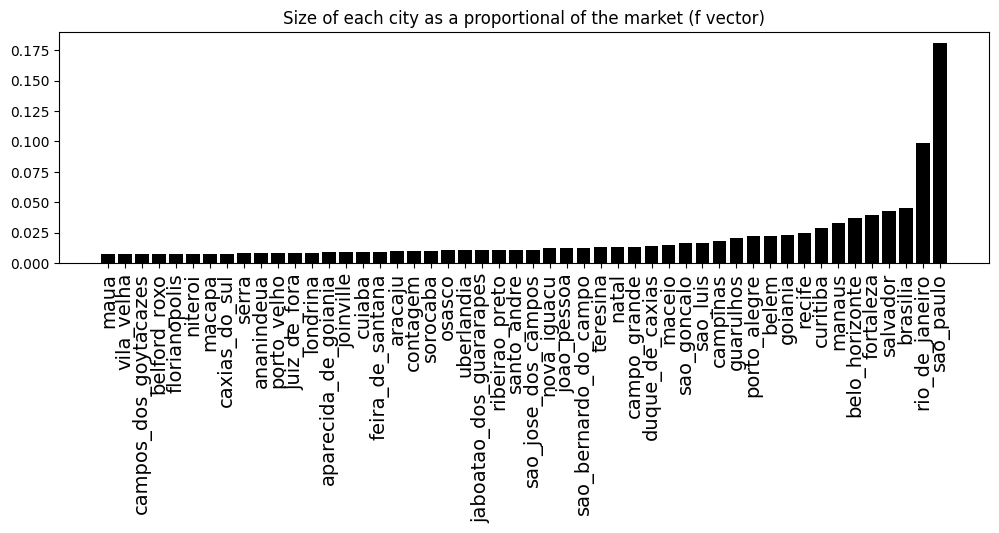

In [179]:
plt.figure(figsize=(12,3))
plt.bar(f.sort_values().index, f.sort_values().values)
plt.title("Size of each city as a proportional of the market (f vector)")
plt.xticks(rotation=90, fontsize=14);

### Trying a Random Set of Treated Units


In [182]:
y_avg = df_piv.dot(f)
geos = list(df_piv.columns)
n_tr = 5

In [184]:
np.random.seed(1)
rand_geos = np.random.choice(geos, n_tr, replace=False)
rand_geos

array(['manaus', 'recife', 'sao_bernardo_do_campo', 'salvador', 'aracaju'],
      dtype='<U23')

In [186]:
def get_sc(geos, df_sc, y_mean_pre):
    
    model = SyntheticControl(fit_intercept=True)
    model.fit(df_sc[geos], y_mean_pre)
    
    selected_geos = geos[np.abs(model.w_) > 1e-5]
    
    return {"geos": selected_geos, "loss": model.loss_ }


get_sc(rand_geos, df_piv, y_avg)

{'geos': array(['salvador', 'aracaju'], dtype='<U23'),
 'loss': 1598627.133821625}

In [188]:
def get_sc_st_combination(treatment_geos, df_sc, y_mean_pre):
    
    treatment_result = get_sc(treatment_geos, df_sc, y_mean_pre)
    
    remaining_geos = df_sc.drop(
        columns=treatment_result["geos"]
    ).columns
    
    control_result = get_sc(remaining_geos, df_sc, y_mean_pre)

    return {"st_geos": treatment_result["geos"],
            "sc_geos": control_result["geos"],
            "loss": treatment_result["loss"] + control_result["loss"]}


resulting_geos = get_sc_st_combination(rand_geos, df_piv, y_avg)

In [125]:
resulting_geos.get("st_geos")

array(['salvador'], dtype='<U23')

In [127]:
len(resulting_geos.get("st_geos")) + len(resulting_geos.get("sc_geos"))

36

/opt/anaconda3/envs/taskb_env_py38/lib/python3.8/site-packages/cvxpy/reductions/solvers/solving_chain.py:356: FutureWarning: 
    You specified your problem should be solved by ECOS. Starting in
    CXVPY 1.6.0, ECOS will no longer be installed by default with CVXPY.
    Please either add ECOS as an explicit install dependency to your project
    or switch to our new default solver, Clarabel, by either not specifying a
    solver argument or specifying ``solver=cp.CLARABEL``. To suppress this
    warning while continuing to use ECOS, you can filter this warning using
    Python's ``warnings`` module until you are using 1.6.0.
    
  warnings.warn(ECOS_DEP_DEPRECATION_MSG, FutureWarning)
/opt/anaconda3/envs/taskb_env_py38/lib/python3.8/site-packages/cvxpy/reductions/solvers/solving_chain.py:356: FutureWarning: 
    You specified your problem should be solved by ECOS. Starting in
    CXVPY 1.6.0, ECOS will no longer be installed by default with CVXPY.
    Please either add ECOS as an exp

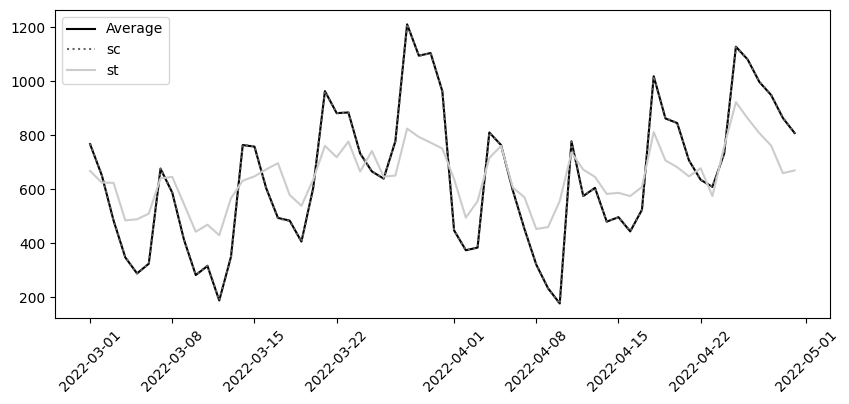

In [129]:
synthetic_tr = SyntheticControl(fit_intercept=True)
synthetic_co = SyntheticControl(fit_intercept=True)

synthetic_tr.fit(df_piv[resulting_geos.get("st_geos")], y_avg)
synthetic_co.fit(df_piv[resulting_geos.get("sc_geos")], y_avg)

plt.figure(figsize=(10,4))
plt.plot(y_avg, label="Average")
plt.plot(y_avg.index, synthetic_co.predict(df_piv[resulting_geos.get("sc_geos")]), label="sc", ls=":")
plt.plot(y_avg.index, synthetic_tr.predict(df_piv[resulting_geos.get("st_geos")]), label="st")


plt.xticks(rotation=45)
plt.legend()

### Random Search


In [206]:
from joblib import Parallel, delayed
from toolz import partial
import numpy as np

np.random.seed(1)

geo_samples = [np.random.choice(geos, n_tr, replace=False) 
               for _ in range(1000)]

est_combination = partial(get_sc_st_combination,
                          df_sc=df_piv,
                          y_mean_pre=y_avg)

def safe_est(geo_sample):
    try:
        return est_combination(geo_sample)
    except Exception as e:
        return {"error": repr(e)}

results = Parallel(n_jobs=4)(
    delayed(safe_est)(geos)      
    for geos in geo_samples
)

In [217]:
valid_results = [r for r in results if isinstance(r, dict) and "loss" in r]

valid_results = [r for r in valid_results if r["loss"] is not None]

len(valid_results)

resulting_geos = min(valid_results, key=lambda x: x["loss"])


In [219]:
resulting_geos.get("st_geos")

array(['brasilia', 'guarulhos', 'aracaju', 'rio_de_janeiro'], dtype='<U23')

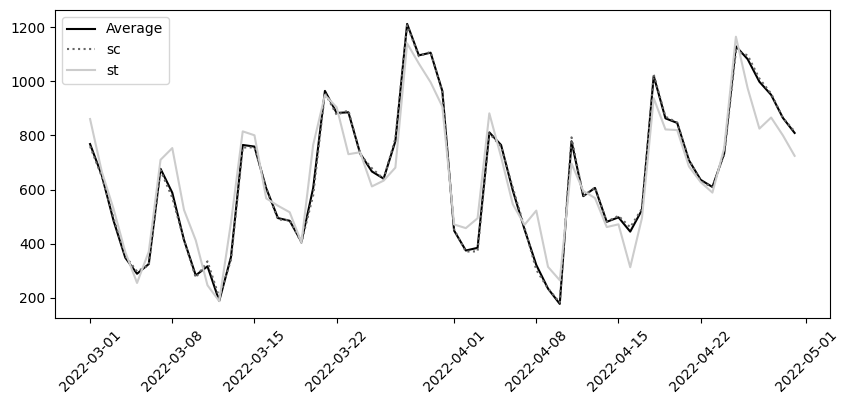

In [221]:
synthetic_tr = SyntheticControl(fit_intercept=True)
synthetic_co = SyntheticControl(fit_intercept=True)

synthetic_tr.fit(df_piv[resulting_geos.get("st_geos")], y_avg)
synthetic_co.fit(df_piv[resulting_geos.get("sc_geos")], y_avg)


plt.figure(figsize=(10,4))
plt.plot(y_avg, label="Average")
plt.plot(y_avg.index, synthetic_co.predict(df_piv[resulting_geos.get("sc_geos")]), label="sc", ls=":")
plt.plot(y_avg.index, synthetic_tr.predict(df_piv[resulting_geos.get("st_geos")]), label="st")


plt.xticks(rotation=45)
plt.legend()


## Switchback Experiment


In [224]:
df = pd.read_csv("./data/sb_exp_every.csv")
df.head()

,d,delivery_time,delivery_time_1,delivery_time_0,tau
0,1,2.84,2.84,5.84,-3.0
1,0,4.49,1.49,6.49,-5.0
2,0,7.27,2.27,8.27,-6.0
3,1,5.27,2.27,8.27,-6.0
4,1,5.59,4.59,10.59,-6.0


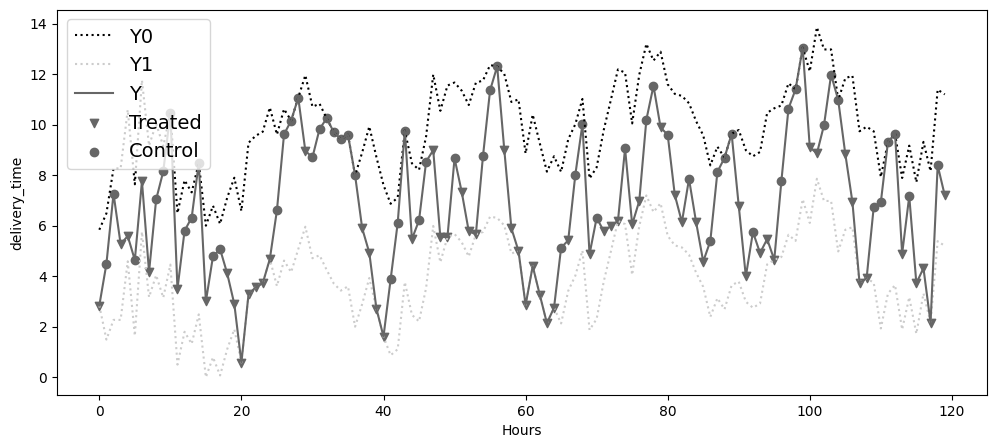

In [226]:
plt.figure(figsize=(12,5))
x = df.index
plt.plot(x, df["delivery_time_0"], ls=":", color="0.0", label="Y0")
plt.plot(x, df["delivery_time_1"], ls=":", color="0.8", label="Y1")
plt.plot(x, df["delivery_time"], color="0.4", label="Y")
plt.scatter(x[df["d"]==1], df["delivery_time"][df["d"]==1], label="Treated", marker="v", color="0.4")
plt.scatter(x[df["d"]==0], df["delivery_time"][df["d"]==0], label="Control", marker="o", color="0.4")
plt.ylabel("delivery_time")
plt.xlabel("Hours")
plt.legend(fontsize=14)


### Potential Outcomes of Sequences

### Estimating the Order of Carryover Effect


In [230]:
df_lags = df.assign(**{
    f"d_l{l}" : df["d"].shift(l) for l in range(7)
})

df_lags[[f"d_l{l}" for l in range(7)]].head()

,d_l0,d_l1,d_l2,...,d_l4,d_l5,d_l6
0,1,NaN,NaN,...,NaN,NaN,NaN
1,0,1.0,NaN,...,NaN,NaN,NaN
2,0,0.0,1.0,...,NaN,NaN,NaN
3,1,0.0,0.0,...,NaN,NaN,NaN
4,1,1.0,0.0,...,1.0,NaN,NaN


In [232]:
import statsmodels.formula.api as smf

model = smf.ols("delivery_time ~" + "+".join([f"d_l{l}"
                                              for l in range(7)]),
                data=df_lags).fit()

model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,9.3270,0.461,20.246,0.000,8.414,10.240
d_l0,-2.9645,0.335,-8.843,0.000,-3.629,-2.300
d_l1,-1.8861,0.339,-5.560,0.000,-2.559,-1.213
d_l2,-1.0013,0.340,-2.943,0.004,-1.676,-0.327
d_l3,0.2594,0.341,0.762,0.448,-0.416,0.935
d_l4,0.1431,0.340,0.421,0.675,-0.531,0.817
d_l5,0.1388,0.340,0.408,0.684,-0.536,0.813
d_l6,0.5588,0.336,1.662,0.099,-0.108,1.225


In [234]:
## remember to remove the intercept
tau_m_hat = model.params[1:].sum() 
se_tau_m_hat = np.sqrt((model.bse[1:]**2).sum()) 
print("tau_m:", tau_m_hat)
print("95% CI:", [tau_m_hat -1.96*se_tau_m_hat,
                  tau_m_hat +1.96*se_tau_m_hat])

tau_m: -4.751686115272028
95% CI: [-6.5087183781545646, -2.994653852389491]


In [236]:
## selecting lags 0, 1 and 2
tau_m_hat = model.params[1:4].sum() 
se_tau_m_hat = np.sqrt((model.bse[1:4]**2).sum()) 
print("tau_m:", tau_m_hat)
print("95% CI:", [tau_m_hat -1.96*se_tau_m_hat,
                  tau_m_hat +1.96*se_tau_m_hat])

tau_m: -5.851856895442299
95% CI: [-7.000105171362171, -4.703608619522426]


### Design Based Estimation


In [239]:
rad_points_3 = np.array([True, False, False]*(2))
rad_points_3

array([ True, False, False,  True, False, False])

In [241]:
rad_points_3.cumsum()

array([1, 1, 1, 2, 2, 2])

In [243]:
from numpy.lib.stride_tricks import sliding_window_view

m = 2
sliding_window_view(rad_points_3.cumsum(), window_shape=m+1)

array([[1, 1, 1],
       [1, 1, 2],
       [1, 2, 2],
       [2, 2, 2]])

In [245]:
np.diff(sliding_window_view(rad_points_3.cumsum(), 3), axis=1)

array([[0, 0],
       [0, 1],
       [1, 0],
       [0, 0]])

In [247]:
n_rand_windows = np.concatenate([
    [np.nan]*m,
    np.diff(sliding_window_view(rad_points_3.cumsum(), 3),
            axis=1).sum(axis=1)+1
])

n_rand_windows

array([nan, nan,  1.,  2.,  2.,  1.])

In [249]:
p=0.5
p**n_rand_windows

array([ nan,  nan, 0.5 , 0.25, 0.25, 0.5 ])

In [251]:
def compute_p(rand_points, m, p=0.5):
    n_windows_last_m = np.concatenate([
        [np.nan]*m,
        np.diff(sliding_window_view(rand_points.cumsum(), m+1),
                axis=1).sum(axis=1)+1
    ])
    return p**n_windows_last_m

compute_p(np.ones(6)==1, 2, 0.5)

array([  nan,   nan, 0.125, 0.125, 0.125, 0.125])

In [253]:
rand_points = np.array([True, False, False, True, False, True, False])
compute_p(rand_points, 2, 0.5)

array([ nan,  nan, 0.5 , 0.25, 0.25, 0.25, 0.25])

In [255]:
def last_m_d_equal(d_vec, d, m):
    return np.concatenate([
        [np.nan]*m,
        (sliding_window_view(d_vec, m+1)==d).all(axis=1)
    ])

print(last_m_d_equal([1, 1, 1, 0, 0, 0], 1, m=2))
print(last_m_d_equal([1, 1, 1, 0, 0, 0], 0, m=2))

[nan nan  1.  0.  0.  0.]
[nan nan  0.  0.  0.  1.]


In [257]:
def ipw_switchback(d, y, rand_points, m, p=0.5):
    
    p_last_m_equal_1 = compute_p(rand_points, m=m, p=p)
    p_last_m_equal_0 = compute_p(rand_points, m=m, p=1-p)
    
    last_m_is_1 = last_m_d_equal(d,1,m)
    last_m_is_0 = last_m_d_equal(d,0,m)
  
    y1_rec = y*last_m_is_1/p_last_m_equal_1
    y0_rec = y*last_m_is_0/p_last_m_equal_0
    
    return np.mean((y1_rec-y0_rec)[m:])

In [259]:
ipw_switchback(df["d"],
               df["delivery_time"],
               np.ones(len(df))==1,
               m=2, p=0.5)

-7.426440677966101

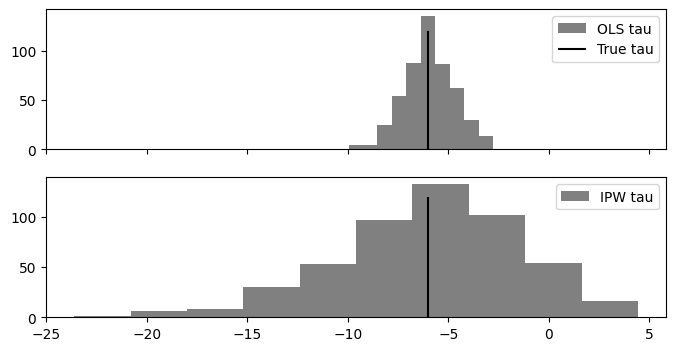

In [261]:
from matplotlib import pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess


def gen_d(rand_points, p):
    result = [np.random.binomial(1, p)]
    
    for t in rand_points[1:]:
        result.append(np.random.binomial(1, p)*t + (1-t)*result[-1])
    
    return np.array(result)


def y_given_d(d, effect_params, T, seed=None):
    np.random.seed(seed) if not seed is None else None
    x = np.arange(1, T+1)
    return (np.log(x+1)
            + 2*np.sin(x*2*np.pi/24)
            + np.convolve(~d.astype(bool), effect_params)[:-(len(effect_params)-1)]
            + ArmaProcess([3,2,1], 12).generate_sample(T)).round(2)



def gen_data_rand_every():
    effect_params = [3,2,1]
    T=120
    p=0.5
    m=2
    
    d = np.random.binomial(1, 0.5, T)
    y = y_given_d(d, [3,2,1], T)
    rand_points = np.ones(T)==1
    
    return pd.DataFrame(dict(d=d, y=y, rand_points=rand_points))


def tau_ols(df):
    df_lags = df.assign(**{
        f"d_l{l}" : df["d"].shift(l) for l in range(3)
    })
    model = smf.ols("y ~" + "+".join([f"d_l{l}" for l in range(3)]),data=df_lags).fit()
    return model.params[1:].sum()

def tau_ipw(df):
    return ipw_switchback(df["d"],
                          df["y"],
                          df["rand_points"],
                          m=2, p=0.5)
    

    
np.random.seed(123)
exps_dfs = [gen_data_rand_every() for _ in range(500)]

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 4))
ols_taus = list(map(tau_ols, exps_dfs))
ax1.hist(ols_taus, label="OLS tau", color="0.5")
ax1.vlines(-6, 0, 120, color="0", label="True tau")
ax1.legend()

ipw_taus = list(map(tau_ipw, exps_dfs))
ax2.hist(ipw_taus, label="IPW tau", color="0.5");
ax2.vlines(-6, 0, 120,  color="0")
ax2.legend()


### Optimal Switchback Design


In [263]:
m = 2
T = 12
n = T/m
np.isin(
    np.arange(1, T+1),
    [1] + [i*m+1 for i in range(2, int(n)-1)]
)*1

array([1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0])

In [264]:
m = 3
T = 15
n = T/m
np.isin(
    np.arange(1, T+1),
    [1] + [i*m+1 for i in range(2, int(n)-1)]
)*1

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0])

In [265]:
def gen_d(rand_points, p):
    result = [np.random.binomial(1, p)]
    
    for t in rand_points[1:]:
        result.append(np.random.binomial(1, p)*t + (1-t)*result[-1])
    
    return np.array(result)

T = 120
m = 2

def gen_exp(rand_points, T):
    effect_params = [3,2,1]
    p=0.5
    
    d = gen_d(rand_points, p=p)
    y = y_given_d(d, [3,2,1], T)

    return pd.DataFrame(dict(d=d, y=y, rand_points=rand_points))


every_1 = np.array([True]*T)
every_3 = np.array([True, False, False]*(T//3))
n = T//m
opt = np.isin(
    np.arange(1, T+1),
    [1] + [i*m+1 for i in range(2, int(n)-1)]
)

np.random.seed(123)
exps_every_1 = [gen_exp(every_1, T) for _ in range(1000)]
exps_every_3 = [gen_exp(every_3, T) for _ in range(1000)]
exps_opt = [gen_exp(opt, T) for _ in range(1000)]

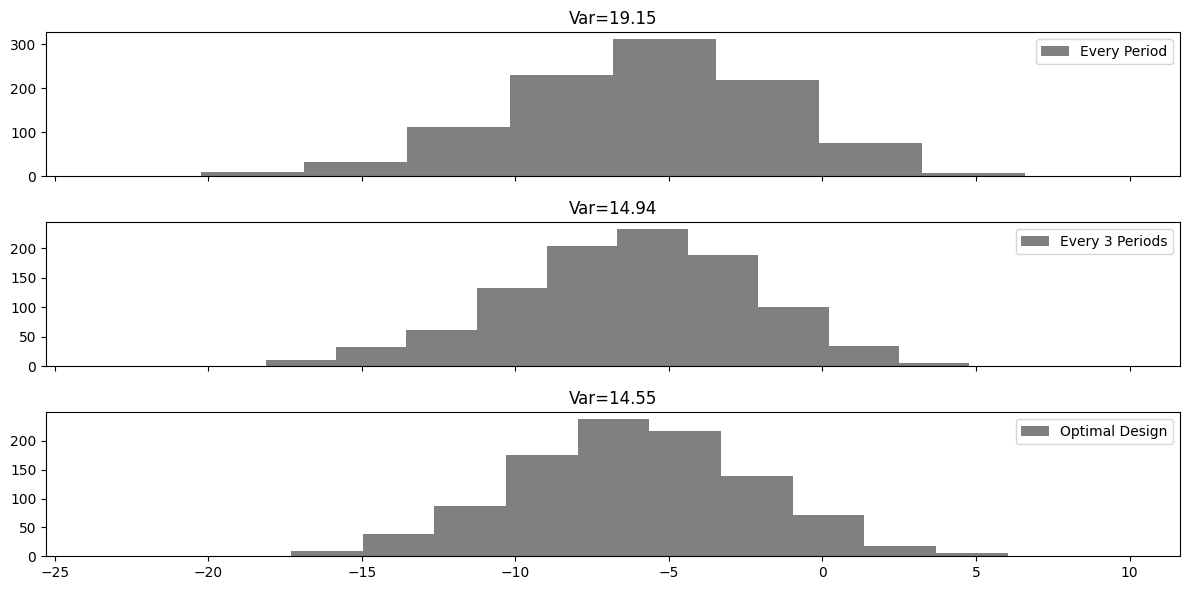

In [266]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(12, 6))
ax1, ax2, ax3 = axs.ravel()

taus_every_1_ipw = list(map(tau_ipw, exps_every_1))
ax1.hist(taus_every_1_ipw, label="Every Period", color="0.5")
ax1.set_title(f"Var={np.round(np.var(taus_every_1_ipw), 2)}")
ax1.legend()


taus_every_3_ipw = list(map(tau_ipw, exps_every_3))
ax2.hist(taus_every_3_ipw, label="Every 3 Periods", color="0.5");
ax2.set_title(f"Var={np.round(np.var(taus_every_3_ipw), 2)}")
ax2.legend()

taus_opt_ipw = list(map(tau_ipw, exps_opt))
ax3.hist(taus_opt_ipw, label="Optimal Design", color="0.5");
ax3.set_title(f"Var={np.round(np.var(taus_opt_ipw), 2)}")
ax3.legend()

plt.tight_layout()

### Robust Variance


In [268]:
df_opt = pd.read_csv("./data/sb_exp_opt.csv")
df_opt.head(6)

,rand_points,d,delivery_time
0,True,0,5.84
1,False,0,5.40
2,False,0,8.86
3,False,0,8.79
4,True,0,10.93
5,False,0,7.02


In [272]:
tau_hat = ipw_switchback(df_opt["d"],
                         df_opt["delivery_time"],
                         df_opt["rand_points"],
                         m=2, p=0.5)

tau_hat

-9.921016949152545

In [273]:
np.vstack(np.hsplit(np.array([1,1,1,2,2,3]), 3))

array([[1, 1],
       [1, 2],
       [2, 3]])

In [274]:
np.diff(np.vstack(np.hsplit(np.array([1,1,0,0,0,0]), 3))[:, 0]) == 0

array([False,  True])

In [275]:
def var_opt_design(d_opt, y_opt, T, m):
    
    assert ((T//m == T/m)
            & (T//m >= 4)), "T must be divisible by m and T/m >= 4"
    
    # discard 1st block
    y_m_blocks = np.vstack(np.hsplit(y_opt, int(T/m))).sum(axis=1)[1:]
    
    # take 1st column
    d_m_blocks = np.vstack(np.split(d_opt, int(T/m))[1:])[:, 0] 
    
    return (
        8*y_m_blocks[0]**2 
        + (32*y_m_blocks[1:-1]**2*(np.diff(d_m_blocks)==0)[:-1]).sum()
        + 8*y_m_blocks[-1]**2 
    ) / (T-m)**2

In [277]:
se_hat = np.sqrt(var_opt_design(df_opt["d"],
                                df_opt["delivery_time"],
                                T=120, m=2))

[tau_hat - 1.96*se_hat, tau_hat + 1.96*se_hat]

[-18.490627362048095, -1.351406536256997]

## Key Ideas


Geo experiment assign treatment at the geographic level rather than the user level, which is useful when user-level randomization is impossible. A major challenge is that different geos naturally differ from one another, so balancing treatment and control is difficult and variance tends to be very high. Power requirements are usually large because average outcomes vary a lot across cities.

Synthetic Control provides a way to build a counterfactual for a treated group by forming a weighted combination of other geos. The method chooses non-negative weights that sum to one and tries to match the pre-period outcome pattern. In this lab, Synthetic Control is used not only for estimating treatment effects but also for selecting which geos should be treated. For any proposed treatment set, SC is fitted on the treated geos and on the remaining geos separately, and the overall fit loss is used as a criterion for how good that assignment is. A random search over many possible geo combinations is then performed, and the combination with the smallest loss is chosen. This creates a treatment and control group that best reproduce the overall pre-period trend.

Switchback experiments assign treatment across time rather than across users or geos. Each time period receives either treatment or control. These designs are useful when the same population keeps interacting with the system repeatedly, such as delivery systems or ranking algorithms. A crucial issue in switchbacks is the carryover effect: treatment in one period can influence outcomes in subsequent periods. The lab estimates carryover by regressing the outcome on current and lagged treatment indicators and identifies that only the first few lags matter, which defines the order of the carryover effect.

Because carryover causes bias for naive estimators, the lab uses an inverse-probability-weighted estimator designed specifically for switchback experiments. This estimator reweights observations depending on how many randomization points occurred in the last several periods. It removes the bias that arises when the treatment pattern is autocorrelated or when future outcomes still feel the effect of past treatment. The results show that ordinary least squares is biased under carryover, while the IPW estimator accurately recovers the true average treatment effect.